SVM Worksflow

In [11]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
data = pd.read_csv("windowed.csv")    # data could be changed (windowing and feature extraction)

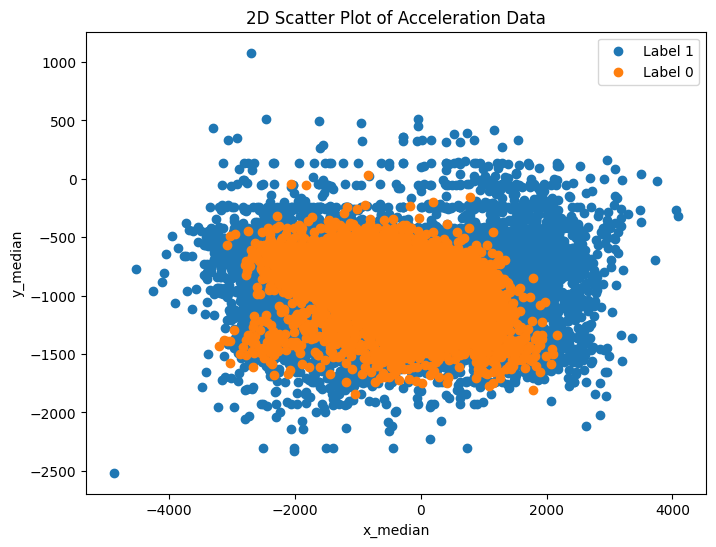

In [13]:
plt.figure(figsize=(8, 6))
for label in data['Label'].unique():
    subset = data[data['Label'] == label]
    plt.scatter(subset['x_median'], subset['y_median'], label=f"Label {label}")

plt.xlabel("x_median")
plt.ylabel("y_median")
plt.title("2D Scatter Plot of Acceleration Data")
plt.legend()
plt.show()

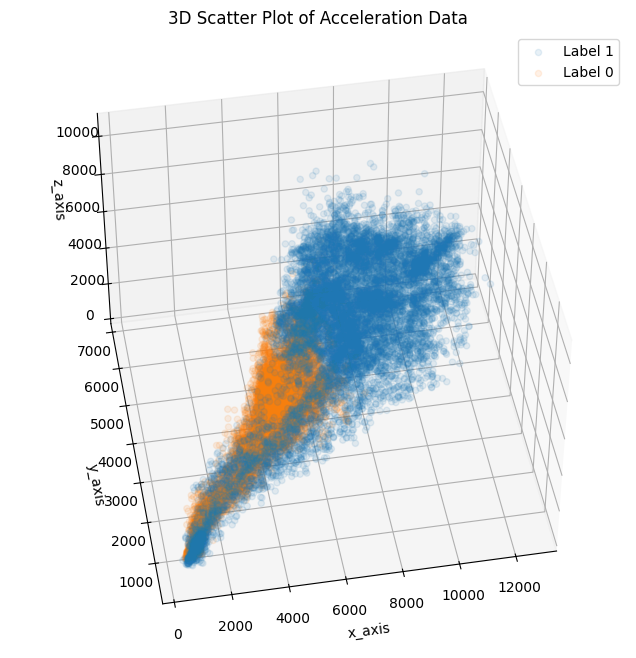

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for label in data['Label'].unique():
    subset = data[data['Label'] == label]
    ax.scatter(subset['x_std'], subset['y_std'], subset['z_std'], label=f"Label {label}", alpha=0.1)

ax.set_xlabel("x_axis")
ax.set_ylabel("y_axis")
ax.set_zlabel("z_axis")
ax.set_title("3D Scatter Plot of Acceleration Data")
ax.legend()
ax.view_init(45, -100)
plt.show()

In [14]:
# Split the data into subsets
X = data.drop(columns="Label")
y = data["Label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
svm_model = SVC(kernel='linear', C=1.0, random_state=42, class_weight="balanced")
svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', kernel='linear', random_state=42)

In [17]:
y_pred_train = svm_model.predict(X_train)
y_pred_test = svm_model.predict(X_test)

In [18]:
print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

Training Accuracy: 0.9959775296483806
Test Accuracy: 0.9963938973647711

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1427
           1       1.00      1.00      1.00      2178

    accuracy                           1.00      3605
   macro avg       1.00      1.00      1.00      3605
weighted avg       1.00      1.00      1.00      3605



In [10]:
svm_model.score(X_test, y_test)

0.9963938973647711